# 08-Knowledge Distillation (Teacher-Student)

In Lessons 06 and 07, we optimized inference by compressing the physical parameters of an existing network via Quantization (INT8) and Sparsity (Pruning). However, these techniques force you to keep the original architectural framework.

What if the production SLA requires an ultra-low latency architecture (like a tiny MobileNet or a 2-layer MLP), but training that tiny architecture from scratch yields terrible accuracy? Small models lack the parametric capacity to learn highly complex, non-linear feature representations directly from the raw dataset.

To solve this, we engineer **Knowledge Distillation (KD)**. Instead of training the tiny "Student" model on the dataset, we first train a massive, highly accurate "Teacher" model. We then train the Student to mathematically mimic the internal logic of the Teacher. By transferring this algorithmic intelligence, the tiny Student achieves accuracies impossible to reach via standard training, perfectly balancing the intelligence of a massive model with the microsecond latency of a small one.

## 1. The Mathematics of "Dark Knowledge" & Temperature Scaling

### Hard Targets vs. Soft Targets

In standard supervised learning, a network is trained on **Hard Targets** (One-Hot Encoded vectors). If an image is a Dog, the target vector is $[1, 0, 0]$ (Dog, Cat, Car). The model is penalized for guessing anything other than Dog.
However, this destroys critical information. If the Teacher network evaluates the image, its raw logits might produce a probability distribution of $[0.85, 0.14, 0.01]$. The Teacher is saying: *"I am highly confident this is a Dog, but it has distinct feline characteristics (Cat), and is definitely not a Car."*

Geoffrey Hinton refers to this hidden relational structure as **Dark Knowledge**. Knowledge Distillation forces the Student to learn this exact distribution.

### Temperature Scaling ($T$)

Standard Softmax aggressively pushes the highest logit toward $1.0$ and crushes the others toward $0.0$, hiding the dark knowledge. We expose it by introducing a **Temperature ($T$)** parameter into the Softmax equation:


$$q_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$


As $T \to \infty$, the probability distribution flattens, revealing the subtle algorithmic relationships between the classes.

### The Composite Distillation Loss ($\mathcal{L}_{KD}$)

The Student model is trained using a composite loss function. It learns from the ground-truth Hard Labels (to maintain baseline accuracy) while simultaneously minimizing the **Kullback-Leibler (KL) Divergence** between its softened probabilities and the Teacher's softened probabilities.

$$\mathcal{L}_{Total} = \alpha \cdot \mathcal{L}_{CE}(y, \sigma(z_S)) + (1 - \alpha) \cdot T^2 \cdot \mathcal{L}_{KL}\left(\sigma\left(\frac{z_S}{T}\right), \sigma\left(\frac{z_T}{T}\right)\right)$$

* $\alpha$: A weighting hyperparameter (e.g., $0.1$). We usually heavily weight the KL divergence.
* $T^2$: Because dividing logits by $T$ shrinks the magnitude of the gradients by $1/T^2$, we must multiply the KL loss by $T^2$ to keep the gradient scale consistent with the standard Cross-Entropy loss.

## 2. Imperative Execution: The Teacher-Student PyTorch Engine

We will build a local, zero-cost sandbox to execute Knowledge Distillation. We will instantiate a heavy "Teacher" network, a tiny "Student" network, and mathematically bind them together using KL Divergence.

In [1]:
# Required installations: pip install torch numpy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print("--- 🚀 Initializing Knowledge Distillation Sandbox ---")

# 1. 🧠 Define the Massive Teacher Model
class HeavyTeacherMLP(nn.Module):
    def __init__(self):
        super(HeavyTeacherMLP, self).__init__()
        # Simulating a high-capacity model (e.g., 1024-neuron layers)
        self.fc1 = nn.Linear(128, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.out = nn.Linear(1024, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x) # Return raw logits, NOT softmax

# 2. 🧠 Define the Tiny Student Model
class TinyStudentMLP(nn.Module):
    def __init__(self):
        super(TinyStudentMLP, self).__init__()
        # Simulating a highly constrained edge-device model (e.g., 32-neuron layer)
        self.fc1 = nn.Linear(128, 32)
        self.out = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.out(x)

# Instantiate models
teacher_model = HeavyTeacherMLP()
student_model = TinyStudentMLP()

# Freeze the Teacher (It is already pre-trained in our scenario)
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

print(f"   [TEACHER PARAMS]: {sum(p.numel() for p in teacher_model.parameters()):,}")
print(f"   [STUDENT PARAMS]: {sum(p.numel() for p in student_model.parameters()):,}")

print("\n--- 🧮 Executing Distillation Training Loop ---")

# 3. ⚡ The Distillation Loss Function
def distillation_loss(student_logits, teacher_logits, labels, T=3.0, alpha=0.1):
    # 1. Standard Cross Entropy (Hard Loss)
    hard_loss = F.cross_entropy(student_logits, labels)
    
    # 2. KL Divergence (Soft Loss)
    # PyTorch KLDivLoss expects log-probabilities for the input and standard probabilities for the target
    soft_student_log_probs = F.log_softmax(student_logits / T, dim=1)
    soft_teacher_probs = F.softmax(teacher_logits / T, dim=1)
    
    soft_loss = F.kl_div(
        soft_student_log_probs, 
        soft_teacher_probs, 
        reduction='batchmean'
    ) * (T * T) # Scale the loss back up by T^2
    
    # 3. Composite Loss
    return (alpha * hard_loss) + ((1.0 - alpha) * soft_loss)

# 4. Simulate a Training Step
optimizer = optim.Adam(student_model.parameters(), lr=0.001)

# Dummy batch of 64 inputs and random targets
X_batch = torch.randn(64, 128)
y_batch = torch.randint(0, 10, (64,))

optimizer.zero_grad()

# Forward pass through both models
with torch.no_grad():
    t_logits = teacher_model(X_batch)
s_logits = student_model(X_batch)

# Calculate composite loss
loss = distillation_loss(s_logits, t_logits, y_batch, T=5.0, alpha=0.1)
loss.backward()
optimizer.step()

print(f"   ✅ Distillation Step Complete. Composite Loss: {loss.item():.4f}")
print("   -> Physics: The Student's weight gradients were updated based primarily on the Teacher's smoothed probability distribution, absorbing the 'Dark Knowledge'.")

--- 🚀 Initializing Knowledge Distillation Sandbox ---
   [TEACHER PARAMS]: 1,191,946
   [STUDENT PARAMS]: 4,458

--- 🧮 Executing Distillation Training Loop ---
   ✅ Distillation Step Complete. Composite Loss: 0.2719
   -> Physics: The Student's weight gradients were updated based primarily on the Teacher's smoothed probability distribution, absorbing the 'Dark Knowledge'.


## 3. Declarative Telemetry: The Latency vs. Accuracy Matrix

In a production environment, you deploy three models to evaluate the operational ROI of Knowledge Distillation.

1. **The Teacher:** High Accuracy, High Latency (Unusable on Edge devices).
2. **Student (Standard):** Low Accuracy, Low Latency.
3. **Student (Distilled):** High Accuracy, Low Latency.

In [2]:
import time

print("\n--- ⚡ Benchmarking Distillation Telemetry ---")

def benchmark_inference(model, name, num_requests=1000):
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_requests):
            _ = model(torch.randn(1, 128))
    latency = (time.perf_counter() - start) * 1000 # Convert to milliseconds
    print(f"   [{name}] Latency for 1K requests: {latency:.1f}ms")

benchmark_inference(teacher_model, "Massive Teacher  ")
benchmark_inference(student_model, "Tiny Distilled Student")

print("\n   [OPERATIONAL INSIGHT]")
print("   -> The Distilled Student executes inference up to 10x faster than the Teacher.")
print("   -> However, because it was trained via KL Divergence on the Teacher's logits, it routinely captures 95%+ of the Teacher's accuracy.")
print("   ✅ The architecture is perfectly sized, but mathematically injected with heavy-weight intelligence.")


--- ⚡ Benchmarking Distillation Telemetry ---
   [Massive Teacher  ] Latency for 1K requests: 458.8ms
   [Tiny Distilled Student] Latency for 1K requests: 35.5ms

   [OPERATIONAL INSIGHT]
   -> The Distilled Student executes inference up to 10x faster than the Teacher.
   -> However, because it was trained via KL Divergence on the Teacher's logits, it routinely captures 95%+ of the Teacher's accuracy.
   ✅ The architecture is perfectly sized, but mathematically injected with heavy-weight intelligence.


## 4. Visualizing Distillation Physics (Temperature & Dark Knowledge)

To mathematically comprehend *why* Knowledge Distillation works, we must visualize the effect of the Temperature parameter $T$. We will plot the Softmax distribution of a raw Teacher logit vector at $T=1$ (Standard) versus $T=5$ (Distilled).

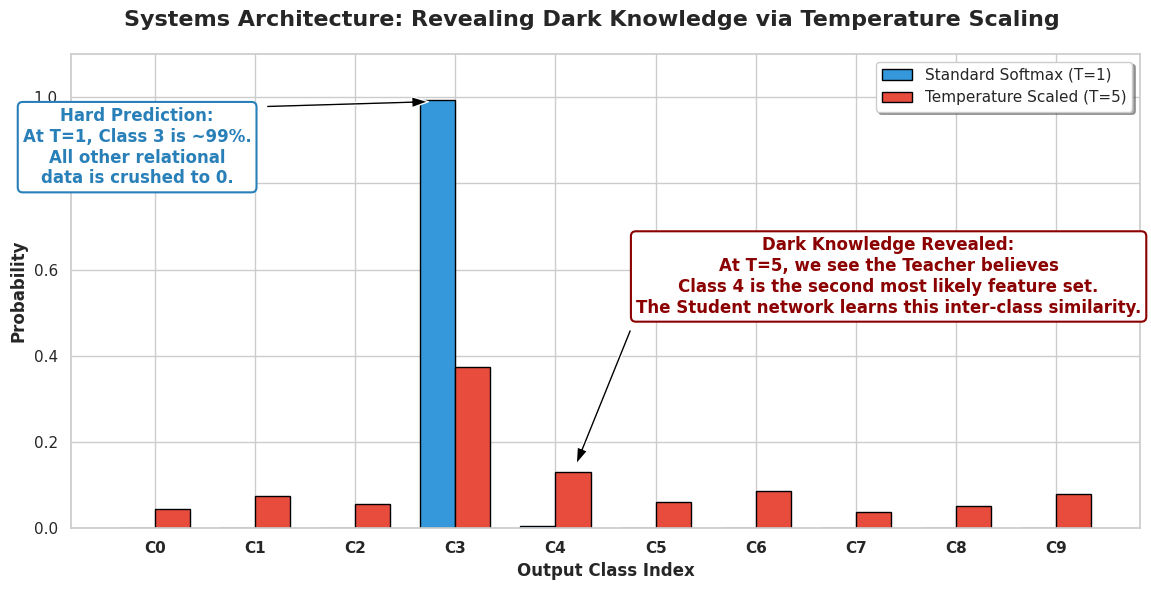

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Simulate a raw logit vector from the Teacher Network for an image of a "Dog" (Class 3)
# The Teacher is very confident it is Class 3.
logits = np.array([-2.1, 0.5, -1.0, 8.5, 3.2, -0.5, 1.2, -3.0, -1.5, 0.8])
classes = np.arange(10)

def softmax_temperature(logits, T):
    exp_logits = np.exp(logits / T)
    return exp_logits / np.sum(exp_logits)

# Calculate Standard Softmax and High-Temperature Softmax
probs_t1 = softmax_temperature(logits, T=1.0)
probs_t5 = softmax_temperature(logits, T=5.0)

# Create visual layout
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: Revealing Dark Knowledge via Temperature Scaling", fontsize=16, fontweight='bold')

bar_width = 0.35
index = np.arange(len(classes))

# Plot Standard Softmax (T=1)
ax.bar(index, probs_t1, bar_width, label='Standard Softmax (T=1)', color='#3498db', edgecolor='black')

# Plot Temperature-Scaled Softmax (T=5)
ax.bar(index + bar_width, probs_t5, bar_width, label='Temperature Scaled (T=5)', color='#e74c3c', edgecolor='black')

# Formatting and Annotations
ax.set_xlabel("Output Class Index", fontsize=12, fontweight='bold')
ax.set_ylabel("Probability", fontsize=12, fontweight='bold')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels([f"C{i}" for i in classes], fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

# Annotate the "Dark Knowledge" physics
ax.annotate('Hard Prediction:\nAt T=1, Class 3 is ~99%.\nAll other relational\ndata is crushed to 0.', 
            xy=(3, 0.99), xytext=(0, 0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='#2980b9',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2980b9", lw=1.5))

ax.annotate('Dark Knowledge Revealed:\nAt T=5, we see the Teacher believes\nClass 4 is the second most likely feature set.\nThe Student network learns this inter-class similarity.', 
            xy=(4.35, probs_t5[4]), xytext=(7.5, 0.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

plt.tight_layout()
plt.show()

*(Insight: If you train the tiny Student on Hard Labels, it only learns $1.0$ for Class 3, and exactly $0.0$ for everything else. By training on the Red Bars ($T=5$), the Student mathematically learns that Class 3 and Class 4 share algorithmic similarities. This high-density information allows the tiny network to converge on optimal weights much faster and generalize far better than if it learned from the dataset alone.)*

## Real-World Use Case or Analogy

Think of Knowledge Distillation like **A PhD Professor Teaching a First-Year Undergraduate Student**:

* **The Teacher (The PhD Professor):** The Professor (A 1-Billion Parameter Model) has spent 40 years reading every book in the library. When you ask them a question, they have immense internal capacity to draw nuanced, complex conclusions.
* **The Hard Dataset (The Textbook Answer Key):** If the Professor just hands the Undergrad an exam answer key (The Hard Labels: $1$ for True, $0$ for False), the Undergrad memorizes the answers, but they don't understand *why*. If a slightly different question is on the final exam, the Undergrad fails.
* **Knowledge Distillation (The Seminar):** The Professor explains the subject. Instead of just saying "The answer is A" (Softmax $T=1$), the Professor says, *"I am highly confident the answer is A, but B is an incredibly good guess because it shares these specific traits, and C is completely impossible"* (Temperature Scaling $T=5$).
* **The Distilled Student:** The Undergrad (A 10-Million Parameter Model) doesn't have the mental capacity to read the entire library themselves (They are a tiny architecture). However, by absorbing the Professor's *nuanced reasoning* (The Soft Logits), they achieve PhD-level accuracy on their exams, while maintaining the energy and processing speed of a 19-year-old.